In [278]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import math
import os

In [279]:
img = cv2.imread('data/fresh\Screen Shot 2018-06-08 at 4.59.49 PM.png')
height, width, channels = img.shape[0:3]
print(height, width, channels)


402 416 3


In [280]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
h,s,v = cv2.split(img_hsv)

v_f = v.flatten()
print(v_f)

[255 255 255 ... 254 240 243]


In [281]:
#getting the frequnecy
freq = np.array(range(256))

for k in v_f:
    freq[k] += 1
# print(freq)

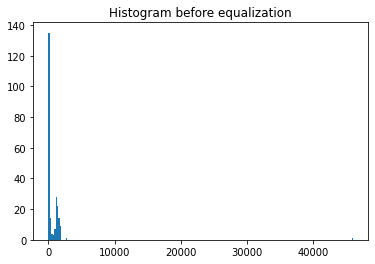

In [282]:
plt.hist(freq, bins=256)
plt.title('Histogram before equalization')
plt.show()

In [283]:
pr = freq/np.sum(freq)
# print(pr)
# print(np.sum(pr))

In [284]:
csum = pr.cumsum()
# print(csum)

In [285]:
sprime = csum * 255
# print(sprime)

In [286]:
rnd=np.round(sprime)
# print(rnd)


In [287]:
hs = np.zeros((256,), dtype=int)
for i in range(256):
  a = int(rnd[i])
  hs[a] += freq[i] 
# print(hs)


<function matplotlib.pyplot.show(close=None, block=None)>

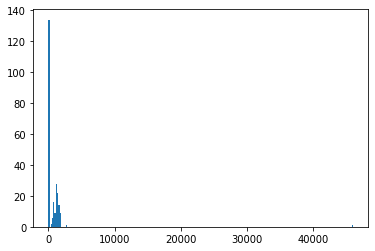

In [288]:
plt.hist(hs,bins=256)
plt.show

In [289]:
o = len(v_f)
print(o)
height, width = img.shape[0:2]

for i in range(o):
  a = v_f[i]
  v_f[i] = rnd[a]

new_v = np.reshape(v_f, (height, width))
# print(new_v)

167232


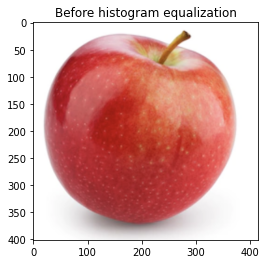

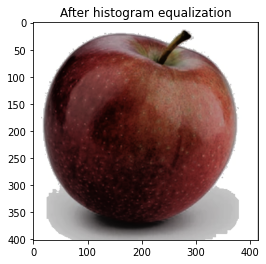

In [290]:
hsv2 = cv2.merge((h,s,new_v))
new_rgb = cv2.cvtColor(hsv2, cv2.COLOR_HSV2RGB)

imgplot = plt.imshow(img_rgb)
plt.title('Before histogram equalization')
plt.show()

imgnewplot = plt.imshow(new_rgb)
plt.title('After histogram equalization')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


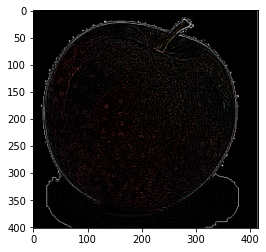

In [291]:
edges = cv2.Laplacian(new_rgb, cv2.CV_16S, ksize=3)

plt.imshow(edges)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


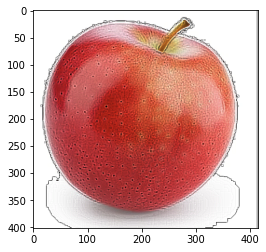

In [292]:


r, g, b = cv2.split(img_rgb)
er, eg, eb= cv2.split(edges)

nr = r + er
ng = g + eg
nb = b + eb

image = cv2.merge((nr,ng,nb))

plt.imshow(image)
plt.show()

In [293]:
img_2d = image.reshape((-1, 3))
img_2d = np.float32(img_2d)

print(img_2d.shape)

(167232, 3)


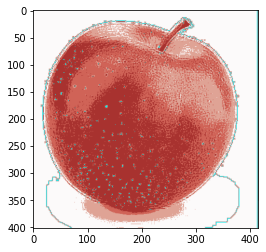

In [297]:
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 300, 0.3)

k = 6
element1, labels, centers = cv2.kmeans(img_2d, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
labels = labels.flatten()
segmented = centers[labels.flatten()]

segmented = segmented.reshape(new_rgb.shape)
plt.imshow(segmented)
plt.show()

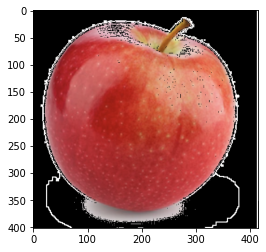

In [298]:
height, width = img_rgb.shape[:2]
    
maxx = segmented.max()

r,g,b = cv2.split(img_rgb)
r_f = r.flatten()
g_f = g.flatten()
b_f = b.flatten()

er, eg, eb = cv2.split(segmented)

er_f = er.flatten()
eg_f = eg.flatten()
eb_f = eb.flatten()

for i in range(len(er_f)):
    if (er_f[i] == maxx  or eg_f[i] == maxx or eb_f[i] == maxx):
        r_f[i] = 0
        g_f[i] = 0
        b_f[i] = 0


new_r = np.reshape(r_f, (height, width))
new_g = np.reshape(g_f, (height, width))
new_b = np.reshape(b_f, (height, width))


removed = cv2.merge((new_r,new_g,new_b))

plt.imshow(removed)
plt.show()
